In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as scp
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from collections import defaultdict
import matplotlib.colors as colors

In [3]:
def slice_by_z_np(data):
    arr = np.array(data)
    z_vals = np.unique(arr[:, 2])
    return {z: arr[arr[:, 2] == z] for z in z_vals}

def get1dfrom2d(x,y,V):
    x0 = 42.996
    y0 = 39.413
    r = np.sqrt((x - x0)**2 + (y - y0)**2)
    nbins = 200
    bins = np.linspace(r.min(), r.max(), nbins + 1)
    inds = np.digitize(r, bins) - 1
    r_centers = 0.5 * (bins[:-1] + bins[1:])
    V_r = np.zeros(nbins)
    for i in range(nbins):
        mask = inds == i
        if np.any(mask):
            V_r[i] = V[mask].mean()
        else:
            V_r[i] = np.nan
    data1d = np.column_stack((r_centers, V_r))
    return data1d

def ArPotential(r,R,epsilon,sigma):
    density =  0.0265
    x = r / R;
    x2 = x*x;
    x4 = x2*x2;
    x6 = x2*x4;
    x8 = x4*x4;
    f1 = 1.0 / (1.0 - x2);
    sigoR3 = pow(sigma/R,3.0);
    sigoR9 = sigoR3*sigoR3*sigoR3;
    v9 = (1.0*pow(f1,9.0)/(240.0)) * ((1091.0 + 11156*x2 + 16434*x4 + 4052*x6 + 35*x8)*scp.ellipe(x2) - 8.0*(1.0 - x2)*(1.0 + 7*x2)*(97.0 + 134*x2 + 25*x4)*scp.ellipk(x2));
    v3 = 2.0*pow(f1,3.0) * ((7.0 + x2)*scp.ellipe(x2) - 4.0*(1.0-x2)*scp.ellipk(x2));
    val = (np.pi*epsilon*sigma*sigma*sigma*density/3.0)*(sigoR9*v9 - sigoR3*v3)
    return val
    
def V_shell(x,R,sigma,epsilon,offset):
    return ArPotential(x,R,epsilon,sigma)  + offset

In [27]:
data = np.loadtxt('../data/He_TPI_samples_xyz.dat',skiprows=1)
slices = slice_by_z_np(data)
zvals = np.array(list(slices.keys()))
cmap = plt.get_cmap('twilight_shifted')
norm = colors.TwoSlopeNorm(vmin=zvals.min(), vcenter=0.0, vmax=107 + zvals.min())

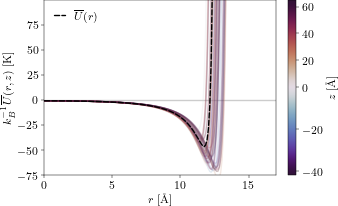

In [29]:
with plt.style.context('../include/aps.mplstyle'):
    figsize = plt.rcParams['figure.figsize']
    fig,axs = plt.subplots(1,1,figsize=(figsize[0],figsize[1]), constrained_layout=True)
    vals = []
    for k,key in enumerate(zvals):
        slice = np.array(slices[key])
        data1D = get1dfrom2d(slice[:, 0],slice[:, 1],slice[:, 3])
        vals.append(data1D[:,1])
        axs.plot(data1D[:,0],data1D[:,1],color=cmap(norm(key)),alpha=0.2)
    avg_z = np.mean(np.array(vals),axis=0)
    xy = data[:, :2]
    unique_xy, inverse = np.unique(xy, axis=0, return_inverse=True)
    V_avg = np.bincount(inverse, weights=data[:, 3]) / np.bincount(inverse)
    data2d = np.column_stack((unique_xy, V_avg))
    data1Davg = get1dfrom2d(data2d[:, 0],data2d[:, 1],data2d[:, 2])
    axs.plot(data1Davg[:,0],data1Davg[:,1],color='k',linestyle='--',label=r'$\overline{U}(r)$')
    axs.axhline(y=0,color='0.8',zorder=-1)
    axs.set_ylim(-75,99.9)
    axs.set_xlim(0,17)
    axs.set_xlabel(r'$r\; [{\rm \AA}]$')
    axs.set_ylabel(r'$k_B^{-1}\overline{U}(r,z)\; [\mathrm{K}]$')
    axs.legend()
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=axs, label=r'$z\; [{\rm \AA}]$')
    plt.savefig('../figures/zdisorder.svg')
    plt.show()